EDA Cuantitativo y HURST (DFA)

Setup y datos 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf

# Activo de análisis — elige uno, sugiero TSLA porque tiene los resultados más ricos
TICKER = "TSLA"
data = yf.download(TICKER, start="2020-01-01", end="2024-12-31")["Close"]
if isinstance(data, pd.DataFrame):
    data = data.squeeze()

r = np.log(data / data.shift(1)).dropna()
print(f"Activo: {TICKER}")
print(f"Periodo: {data.index[0].date()} a {data.index[-1].date()}")
print(f"N observaciones: {len(r)}")

[*********************100%***********************]  1 of 1 completed

Activo: TSLA
Periodo: 2020-01-02 a 2024-12-30
N observaciones: 1256


Esatdisticas descriptivas y distribucion

Media diaria:      0.002132
Std diaria:        0.042211
Retorno anualizado: 53.73%
Vol. anualizada:    67.01%
Skewness:          -0.1135
Kurtosis (exceso): 3.2405


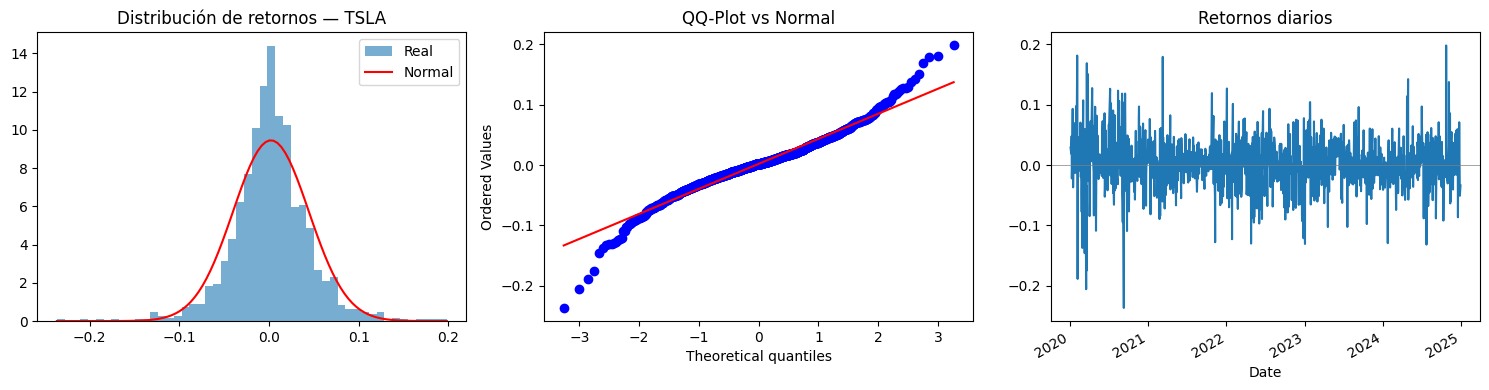

In [2]:
print(f"Media diaria:      {r.mean():.6f}")
print(f"Std diaria:        {r.std():.6f}")
print(f"Retorno anualizado: {r.mean()*252*100:.2f}%")
print(f"Vol. anualizada:    {r.std()*np.sqrt(252)*100:.2f}%")
print(f"Skewness:          {r.skew():.4f}")
print(f"Kurtosis (exceso): {r.kurtosis():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(r, bins=50, density=True, alpha=0.6, label="Real")
x = np.linspace(r.min(), r.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r-', label="Normal")
axes[0].set_title(f"Distribución de retornos — {TICKER}")
axes[0].legend()

stats.probplot(r, dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot vs Normal")

r.plot(ax=axes[2])
axes[2].set_title("Retornos diarios")
axes[2].axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

Test de normalidad y ajuste t-Student

In [4]:
stat, p = stats.shapiro(r.sample(min(500, len(r)), random_state=42))
print(f"Shapiro-Wilk p-value: {p:.6f}")
print(f"¿Normal? {'Sí' if p > 0.05 else 'No — rechazamos normalidad (fat tails esperadas)'}")

nu, mu_t, sigma_t = stats.t.fit(r)
print(f"\nt-Student ajustada: ν={nu:.2f}")

escala_ajustada = r.std() * np.sqrt((nu-2)/nu)
print("\nProbabilidad de pérdida extrema — Normal vs t-Student:")
for umbral in [-0.05, -0.10, -0.15, -0.20, -0.3]:
    p_n = stats.norm.cdf(umbral, r.mean(), r.std())
    p_t = stats.t.cdf(umbral, nu, r.mean(), escala_ajustada)
    print(f"  {umbral*100:.0f}%: Normal={p_n*100:.4f}%  t-Student={p_t*100:.4f}%  "
          f"Ratio={p_t/p_n:.2f}x")

Shapiro-Wilk p-value: 0.000000
¿Normal? No — rechazamos normalidad (fat tails esperadas)

t-Student ajustada: ν=3.77

Probabilidad de pérdida extrema — Normal vs t-Student:
  -5%: Normal=10.8407%  t-Student=7.5081%  Ratio=0.69x
  -10%: Normal=0.7769%  t-Student=1.3340%  Ratio=1.72x
  -15%: Normal=0.0157%  t-Student=0.3681%  Ratio=23.50x
  -20%: Normal=0.0001%  t-Student=0.1371%  Ratio=1632.88x
  -30%: Normal=0.0000%  t-Student=0.0321%  Ratio=782439910.04x


Estacionariedad ADF y memoria ACF

ADF precio:   p=0.2739 → NO estacionario
ADF retornos: p=0.0000 → estacionario


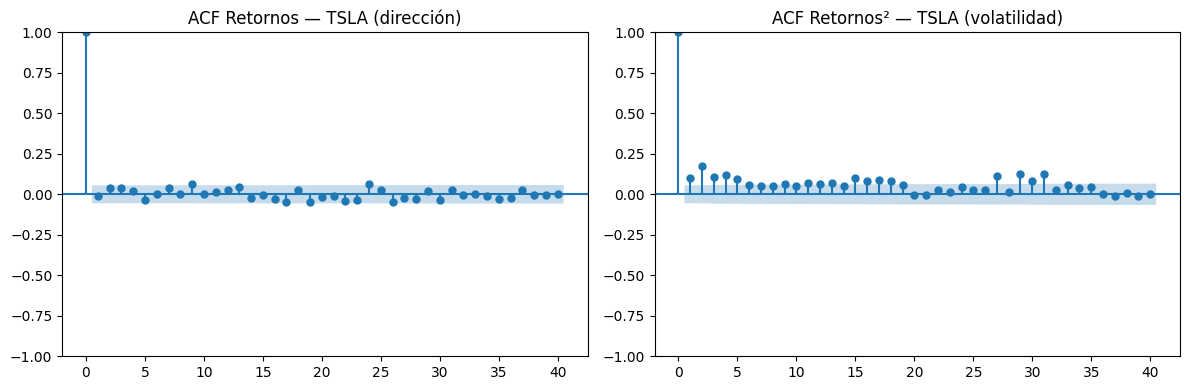

In [5]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

adf_precio = adfuller(data.dropna())
adf_ret = adfuller(r)
print(f"ADF precio:   p={adf_precio[1]:.4f} → {'estacionario' if adf_precio[1]<0.05 else 'NO estacionario'}")
print(f"ADF retornos: p={adf_ret[1]:.4f} → {'estacionario' if adf_ret[1]<0.05 else 'NO estacionario'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(r, lags=40, ax=axes[0], title=f"ACF Retornos — {TICKER} (dirección)")
plot_acf(r**2, lags=40, ax=axes[1], title=f"ACF Retornos² — {TICKER} (volatilidad)")
plt.tight_layout()
plt.show()

Exponente de HURST

Exponente de Hurst — TSLA: H=0.617
→ Trending: memoria de largo plazo, momentum potencial


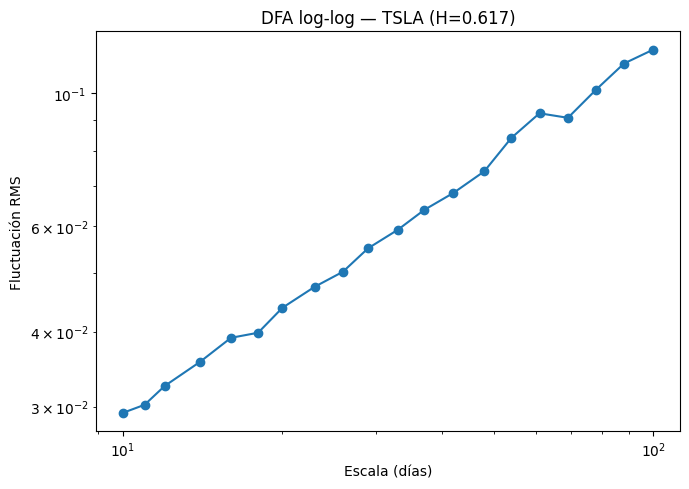

: 

In [ ]:
def hurst_dfa(series, min_scale=10, max_scale=100, n_scales=20):
    series = np.array(series).flatten()
    scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), n_scales).astype(int))
    fluctuations = []
    profile = np.cumsum(series - np.mean(series))
    
    for scale in scales:
        n_segments = len(profile) // scale
        if n_segments < 2:
            continue
        rms_list = []
        for i in range(n_segments):
            segment = profile[i*scale:(i+1)*scale]
            x = np.arange(scale)
            coeffs = np.polyfit(x, segment, 1)
            trend = np.polyval(coeffs, x)
            rms_list.append(np.sqrt(np.mean((segment - trend)**2)))
        fluctuations.append(np.mean(rms_list))
    
    scales_used = scales[:len(fluctuations)]
    H, intercept = np.polyfit(np.log10(scales_used), np.log10(fluctuations), 1)
    return H, scales_used, fluctuations

H, scales_used, fluctuations = hurst_dfa(r.values)
print(f"Exponente de Hurst — {TICKER}: H={H:.3f}")

if H > 0.55:
    print("→ Trending: memoria de largo plazo, momentum potencial")
elif H < 0.45:
    print("→ Mean-reverting: anti-persistente, reversión potencial")
else:
    print("→ H≈0.5: comportamiento cercano a paseo aleatorio (mercado eficiente)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(scales_used, fluctuations, 'o-')
ax.set_xlabel("Escala (días)")
ax.set_ylabel("Fluctuación RMS")
ax.set_title(f"DFA log-log — {TICKER} (H={H:.3f})")
plt.tight_layout()
plt.show()